In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
from google.colab import files
import matplotlib.pyplot as plt

In [ ]:
#чтобы загрузить файлы с данными в блокнот/ Вызвать команду столько раз, сколько файлов надо загрузить
dates = files.upload()

Saving horse_data.csv to horse_data.csv


In [ ]:
df_horse = pd.read_csv('horse_data.csv', sep=',', header=None,usecols=[0,1,3,4,5,6,10,22],names = ['surgery?', 'Age','rectal_temperature','pulse','respiratory_rate','temperature_of_extremities','pain','outcome'])
df_horse.head()

NameError: name 'pd' is not defined

In [ ]:
#Посмотрим уникальные значения на каждом столбце.
# Как то странно заполнен столбец с возрастом - из описания там должны быть толко значения 1, 2, а есть 1 или 9.
# Вместо пустого значения используется ?

for i in df_horse.columns:
  print(i, df_horse[i].unique())

surgery? ['2' '1' '?']
Age [1 9]
rectal_temperature ['38.50' '39.2' '38.30' '39.10' '37.30' '?' '37.90' '38.10' '37.20'
 '38.00' '38.2' '37.60' '37.50' '39.4' '39.90' '38.40' '38.60' '38.3'
 '38.1' '37.80' '37.7' '37.70' '38.20' '37.8' '39.20' '39.00' '35.4'
 '38.90' '37.40' '40.30' '37.9' '37.00' '39.7' '37.6' '38.7' '36.40'
 '37.3' '38.0' '38.80' '39.60' '36.80' '38.4' '39.50' '36.5' '39.40'
 '38.70' '37.4' '38' '36.00' '37.1' '38.9' '39.30' '38.8' '39.5' '37.5'
 '38.5' '37.10' '36.10' '39.3' '36.60' '40.80' '36.90' '38.6' '40.00'
 '36.50' '37.2']
pulse ['66' '88' '40' '164' '104' '?' '48' '60' '80' '90' '72' '42' '92' '76'
 '96' '128' '64' '110' '130' '108' '100' '112' '52' '146' '150' '120'
 '140' '84' '46' '114' '160' '54' '56' '38' '98' '50' '44' '70' '78' '49'
 '30' '136' '132' '65' '86' '129' '68' '36' '45' '124' '184' '75' '82']
respiratory_rate ['28' '20' '24' '84' '35' '?' '16' '36' '12' '52' '48' '21' '60' '34' '42'
 '30' '96' '72' '15' '44' '32' '22' '18' '80' '40' '10' '5

In [ ]:
# Заменим 9 на 2  в столбце Age
df_horse['Age'] = df_horse['Age']. replace (9, 2)

In [ ]:
# Исходя из описания столбцов - пустых значений в столбцах нет. все ячейки заполнены. Но типы данных текстовые. потому по ним не посчитать никакие значения. нужно переводить в числовые
df_horse.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 8 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   surgery?                    300 non-null    object
 1   Age                         300 non-null    int64 
 2   rectal_temperature          300 non-null    object
 3   pulse                       300 non-null    object
 4   respiratory_rate            300 non-null    object
 5   temperature_of_extremities  300 non-null    object
 6   pain                        300 non-null    object
 7   outcome                     300 non-null    object
dtypes: int64(1), object(7)
memory usage: 18.9+ KB


In [ ]:
# заменим ? на Nan
df_horse = df_horse.replace('?',np.nan)
# переведем всю таблицу в числовые типы
df_horse = pd.DataFrame(df_horse, dtype=float)
# посчитаем теперь количество пропущенных значений
df_horse.isna().sum()

surgery?                       1
Age                            0
rectal_temperature            60
pulse                         24
respiratory_rate              58
temperature_of_extremities    56
pain                          55
outcome                        1
dtype: int64

In [ ]:
# Посчитаем статистики для непрерывных параметров: температуры и пульс,частота дыхания.
df_horse[['rectal_temperature',  'respiratory_rate','pulse']].describe()

,rectal_temperature,respiratory_rate,pulse
count,240.000000,242.000000,276.000000
mean,38.167917,30.417355,71.913043
std,0.732289,17.642231,28.630557
min,35.400000,8.000000,30.000000
25%,37.800000,18.500000,48.000000
50%,38.200000,24.500000,64.000000
75%,38.500000,36.000000,88.000000
max,40.800000,96.000000,184.000000


In [ ]:
# посчитаем и посмотрим моду для категориальных параметров в целом
df_horse[['surgery?','Age','temperature_of_extremities','pain','outcome']].mode()


,surgery?,Age,temperature_of_extremities,pain,outcome
0,1.0,1.0,3.0,3.0,1.0


Поищем выбросы

<Axes: xlabel='Age', ylabel='pulse'>

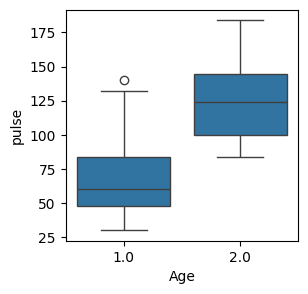

In [ ]:
# в группе возраст пульс - есть выбросы для молодых лошадей.
plt.figure(figsize=(3, 3))
sns.boxplot(x ='Age',y='pulse',data=df_horse)

([0, 1], [Text(0, 0, '1.0'), Text(1, 0, '2.0')])

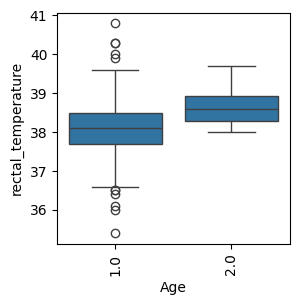

In [ ]:
# в группе возраст температура - есть выбросы снова для молодых лошадей.
plt.figure(figsize=(3, 3))
sns.boxplot(x ='Age',y='rectal_temperature',data=df_horse)
plt.xticks(rotation=90)

([0, 1], [Text(0, 0, '1.0'), Text(1, 0, '2.0')])

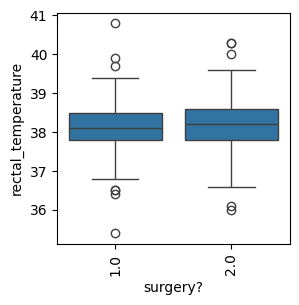

In [ ]:
# в группе операция температура - есть выбросы в обоих группах.
plt.figure(figsize=(3, 3))
sns.boxplot(x ='surgery?',y='rectal_temperature',data=df_horse)
plt.xticks(rotation=90)

([0, 1, 2, 3, 4],
 [Text(0, 0, '1.0'),
  Text(1, 0, '2.0'),
  Text(2, 0, '3.0'),
  Text(3, 0, '4.0'),
  Text(4, 0, '5.0')])

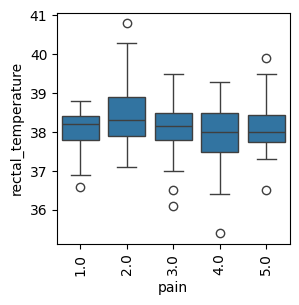

In [ ]:
# в группе оценка состояния- температура- - есть выбросы в всех группах.
plt.figure(figsize=(3, 3))
sns.boxplot(x ='pain',y='rectal_temperature',data=df_horse)
plt.xticks(rotation=90)

([0, 1, 2, 3],
 [Text(0, 0, '1.0'), Text(1, 0, '2.0'), Text(2, 0, '3.0'), Text(3, 0, '4.0')])

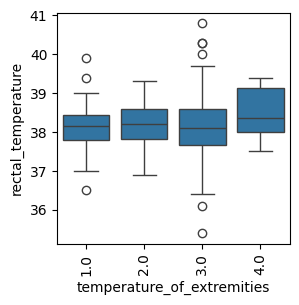

In [ ]:
# в группе оценка темп- температура- - есть выбросы в всех группах.
plt.figure(figsize=(3, 3))
sns.boxplot(x ='temperature_of_extremities',y='rectal_temperature',data=df_horse)
plt.xticks(rotation=90)


([0, 1, 2, 3, 4],
 [Text(0, 0, '1.0'),
  Text(1, 0, '2.0'),
  Text(2, 0, '3.0'),
  Text(3, 0, '4.0'),
  Text(4, 0, '5.0')])

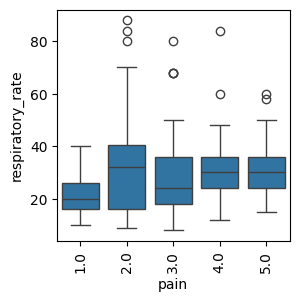

In [ ]:
# в группе оценка состояния - частота дыхания  есть выбросы в всех группах.
plt.figure(figsize=(3, 3))
sns.boxplot(x ='pain',y='respiratory_rate',data=df_horse)
plt.xticks(rotation=90)

([0, 1, 2, 3, 4],
 [Text(0, 0, '1.0'),
  Text(1, 0, '2.0'),
  Text(2, 0, '3.0'),
  Text(3, 0, '4.0'),
  Text(4, 0, '5.0')])

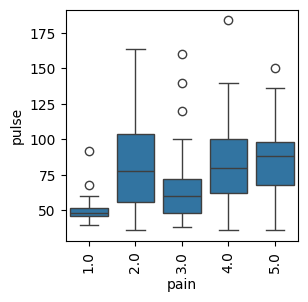

In [ ]:
# в группе оценка состояния - пульс  есть выбросы в всех группах.
plt.figure(figsize=(3, 3))
sns.boxplot(x ='pain',y='pulse',data=df_horse)
plt.xticks(rotation=90)

In [ ]:
# в группе оценка состояния - пульс  есть выбросы в всех группах.
plt.figure(figsize=(3, 3))
sns.boxplot(x ='pain',y='pulse',data=df_horse)
plt.xticks(rotation=90)

Заполним пропуски

In [ ]:
df_h = df_horse.copy()

In [ ]:
#df_h[df_h['surgery?'].isnull()]
df_h.iloc[[132]]

,surgery?,Age,rectal_temperature,pulse,respiratory_rate,temperature_of_extremities,pain,outcome
132,1.0,1.0,38.0,48.0,20.0,3.0,4.0,2.0


In [ ]:
# Заполним пропуски в столбцах surgery?,	Age outcome значением моды

df_h['surgery?'] = df_h['surgery?'].fillna(df_h['surgery?'].fillna(df_h.groupby(['pain'])['surgery?'].transform(lambda x: x.mode()[0])))
df_h['outcome'] = df_h['outcome'].fillna(df_h['outcome'].fillna(df_h.groupby(['pain'])['outcome'].transform(lambda x: x.mode()[0])))
df_h.isna().sum()

surgery?                       0
Age                            0
rectal_temperature            60
pulse                         24
respiratory_rate              58
temperature_of_extremities    56
pain                          55
outcome                        0
dtype: int64

In [ ]:
# заполним оценку состояния лошади модой по группам - операция-возраст-итог
df_h['pain'] = df_h['pain'].fillna(df_h.groupby(['surgery?', 'Age', 'outcome'])['pain'].transform(lambda x: x.mode()[0]))
df_h.isna().sum()

surgery?                       0
Age                            0
rectal_temperature            60
pulse                         24
respiratory_rate              58
temperature_of_extremities    56
pain                           0
outcome                        0
dtype: int64

In [ ]:
# заполним значение температуры в зависимости от оценки температуры. так как есть выбросы то возьмем значение моды. про эти 2 параметра было однозначно сказано что они зависят друг от друга. Но данная операция все равно не убрала часть пропусков
df_h['rectal_temperature'] = df_h['rectal_temperature'].fillna(df_h.groupby(['surgery?','Age', 'temperature_of_extremities'])['rectal_temperature'].transform('median'))
df_h.isna().sum()

surgery?                       0
Age                            0
rectal_temperature            15
pulse                         24
respiratory_rate              58
temperature_of_extremities    56
pain                           0
outcome                        0
dtype: int64

In [ ]:
# Заполним оценку температуры в зависимости от оценки состояния лошади и также и пульс
df_h['temperature_of_extremities'] = df_h['temperature_of_extremities'].fillna(df_h.groupby(['surgery?','Age', 'pain'])['temperature_of_extremities'].transform(lambda x: x.mode()[0]))
df_h['pulse'] = df_h['pulse'].fillna(df_h.groupby(['surgery?','Age', 'pain'])['pulse'].transform('median'))
df_h.isna().sum()

surgery?                       0
Age                            0
rectal_temperature            15
pulse                          0
respiratory_rate              58
temperature_of_extremities     0
pain                           0
outcome                        0
dtype: int64

In [ ]:
# частоту дыхания поставим медианным значениям по группам возраст-оценка температуры
df_h['respiratory_rate'] = df_h['respiratory_rate'].fillna(df_h.groupby(['surgery?','Age', 'temperature_of_extremities'])['respiratory_rate'].transform('median'))
df_h['respiratory_rate'] = df_h['respiratory_rate'].fillna(df_h.groupby(['surgery?','Age', 'pain'])['respiratory_rate'].transform('median'))
df_h.isna().sum()

surgery?                       0
Age                            0
rectal_temperature            15
pulse                          0
respiratory_rate               0
temperature_of_extremities     0
pain                           0
outcome                        0
dtype: int64

In [ ]:
# Пересчитаем температуры по оценке состояния
df_h['rectal_temperature'] = df_h['rectal_temperature'].fillna(df_h.groupby(['surgery?', 'Age', 'outcome'])['rectal_temperature'].transform('median'))
df_h.isna().sum()

surgery?                      0
Age                           0
rectal_temperature            0
pulse                         0
respiratory_rate              0
temperature_of_extremities    0
pain                          0
outcome                       0
dtype: int64

In [ ]:
# Сравним основные статистики до и после устранения пропусков
df_horse[['rectal_temperature',  'respiratory_rate','pulse']].describe()

,rectal_temperature,respiratory_rate,pulse
count,240.000000,242.000000,276.000000
mean,38.167917,30.417355,71.913043
std,0.732289,17.642231,28.630557
min,35.400000,8.000000,30.000000
25%,37.800000,18.500000,48.000000
50%,38.200000,24.500000,64.000000
75%,38.500000,36.000000,88.000000
max,40.800000,96.000000,184.000000


In [ ]:
df_h[['rectal_temperature',  'respiratory_rate','pulse']].describe()

,rectal_temperature,respiratory_rate,pulse
count,300.000000,300.000000,300.00000
mean,38.175500,29.596667,71.88000
std,0.658943,16.163483,27.97369
min,35.400000,8.000000,30.00000
25%,37.900000,20.000000,48.00000
50%,38.150000,26.000000,64.00000
75%,38.500000,35.250000,88.00000
max,40.800000,96.000000,184.00000
